# Energy Consumption Forecasting — Modelling, Evaluation & Explainability


**Input:** `pjme_features.csv` produced by the preprocessing/EDA/feature-engineering notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (14, 5)

import warnings
warnings.filterwarnings('ignore')


## 1. Load Feature Set

In [2]:
DATA_PATH = '/kaggle/input/datasets/siddhant22132/pjme-features/pjme_features.csv'

feat = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
feat.index.name = 'Datetime'
print(feat.shape)
feat.head()


(145224, 20)


,PJME_MW,rolling_z,hour,dayofweek,day,month,quarter,year,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,month_sin,month_cos,is_holiday,lag_24h,lag_168h,rolling_mean_7d,rolling_std_7d
Datetime,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,-0.703504,1,1,8,1,1,2002,8,2,0,0.258819,0.965926,0.5,0.866025,0,26862.0,30393.0,32519.511905,3857.950565
2002-01-08 02:00:00,28670.0,-0.898341,2,1,8,1,1,2002,8,2,0,0.500000,0.866025,0.5,0.866025,0,25976.0,29265.0,32513.869048,3861.770954
2002-01-08 03:00:00,28375.0,-0.971645,3,1,8,1,1,2002,8,2,0,0.707107,0.707107,0.5,0.866025,0,25641.0,28357.0,32510.327381,3865.039821
2002-01-08 04:00:00,28542.0,-0.927925,4,1,8,1,1,2002,8,2,0,0.866025,0.500000,0.5,0.866025,0,25666.0,27899.0,32510.434524,3864.924245
2002-01-08 05:00:00,29261.0,-0.744092,5,1,8,1,1,2002,8,2,0,0.965926,0.258819,0.5,0.866025,0,26328.0,28057.0,32514.261905,3860.646270


## 2. Train / Test Split

Per the proposal, the final 12 months are held out as the test set. All feature engineering
(lags, rolling stats) was already computed causally in the previous notebook, so there is no
leakage across the split.


In [3]:
TARGET = 'PJME_MW'

test_start = feat.index.max() - pd.DateOffset(months=12)
train = feat[feat.index < test_start].copy()
test = feat[feat.index >= test_start].copy()

print(f"Train: {train.index.min()} -> {train.index.max()}  ({len(train):,} rows)")
print(f"Test:  {test.index.min()} -> {test.index.max()}  ({len(test):,} rows)")

feature_cols = [c for c in feat.columns if c not in [TARGET, 'rolling_z']]
print(f"\nFeature columns ({len(feature_cols)}):\n{feature_cols}")


Train: 2002-01-08 01:00:00 -> 2017-08-02 23:00:00  (136,463 rows)
Test:  2017-08-03 00:00:00 -> 2018-08-03 00:00:00  (8,761 rows)

Feature columns (18):
['hour', 'dayofweek', 'day', 'month', 'quarter', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'lag_24h', 'lag_168h', 'rolling_mean_7d', 'rolling_std_7d']


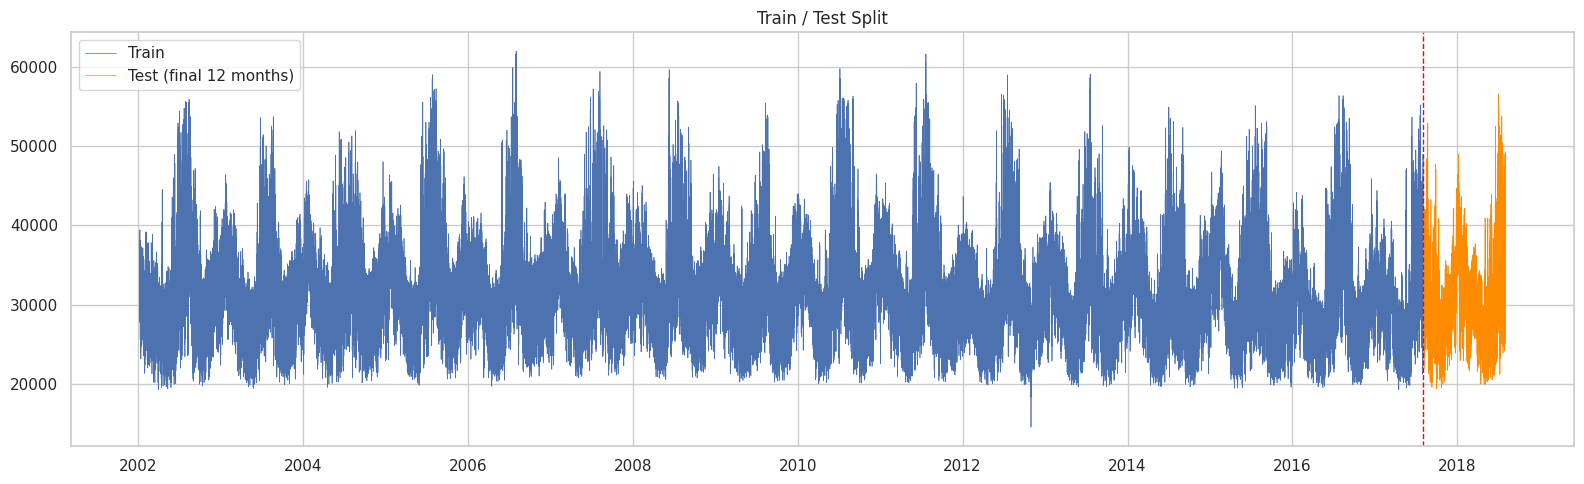

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train.index, train[TARGET], label='Train', linewidth=0.5)
ax.plot(test.index, test[TARGET], label='Test (final 12 months)', linewidth=0.5, color='darkorange')
ax.axvline(test_start, color='red', linestyle='--', linewidth=1)
ax.set_title('Train / Test Split')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Evaluation Metrics

A shared metric function (MAE, RMSE, MAPE) and a results list used consistently across all models.


In [5]:
def evaluate(y_true, y_pred, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

results = []


## 4. Baseline Models

### 4.1 Naive Seasonal (168h lag)

The simplest sensible baseline for hourly load: predict this hour's value using the same hour,
same day-of-week, one week ago. Every other model must beat this to justify its complexity.


In [6]:
naive_pred = test['lag_168h'].values
naive_true = test[TARGET].values

results.append(evaluate(naive_true, naive_pred, 'Naive Seasonal (168h)'))
pd.DataFrame(results)


,Model,MAE,RMSE,MAPE (%)
0,Naive Seasonal (168h),3581.544458,4852.025753,11.217686


### 4.2 SARIMA

Fit on a daily-resampled series to keep this tractable, then evaluated at daily granularity
against the daily-averaged test set (SARIMA on raw hourly data over 10+ years is computationally
prohibitive in a notebook setting).


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

daily_train = train[TARGET].resample('D').mean()
daily_test = test[TARGET].resample('D').mean()

sarima_model = SARIMAX(
    daily_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(daily_test))
results.append(evaluate(daily_test.values, sarima_forecast.values, 'SARIMA (daily)'))
pd.DataFrame(results)


,Model,MAE,RMSE,MAPE (%)
0,Naive Seasonal (168h),3581.544458,4852.025753,11.217686
1,SARIMA (daily),6809.975780,7619.622096,23.551272


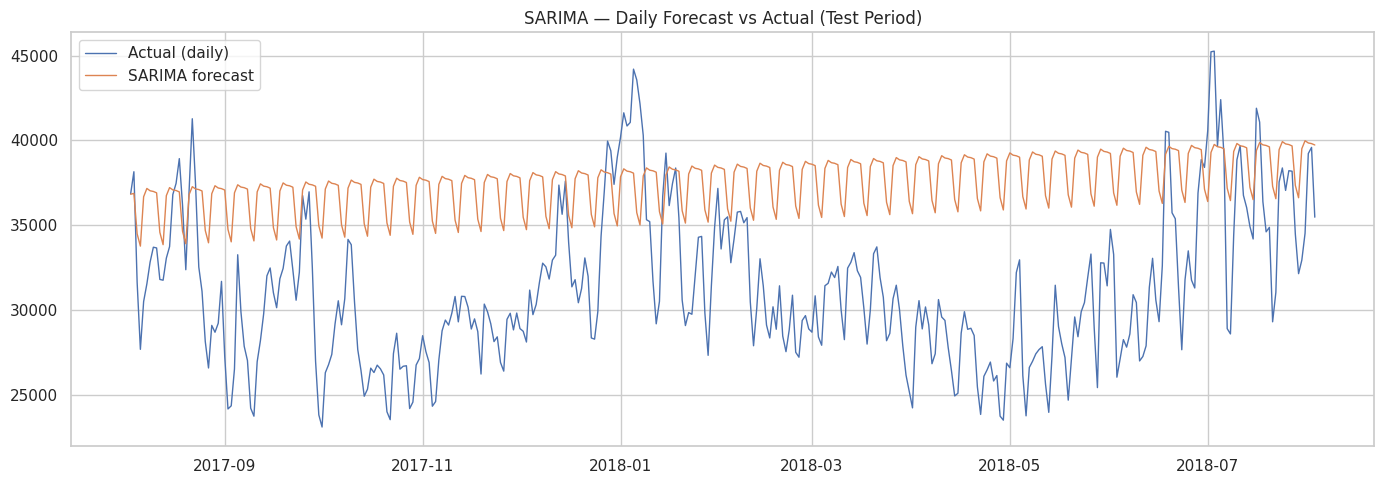

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_test.index, daily_test.values, label='Actual (daily)', linewidth=1)
ax.plot(daily_test.index, sarima_forecast.values, label='SARIMA forecast', linewidth=1)
ax.set_title('SARIMA — Daily Forecast vs Actual (Test Period)')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Gradient Boosting — XGBoost & LightGBM

Trained directly on the engineered tabular features (calendar, lag, rolling stats) at hourly
resolution.


In [9]:
from xgboost import XGBRegressor

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

results.append(evaluate(y_test.values, xgb_pred, 'XGBoost'))
pd.DataFrame(results)


,Model,MAE,RMSE,MAPE (%)
0,Naive Seasonal (168h),3581.544458,4852.025753,11.217686
1,SARIMA (daily),6809.975780,7619.622096,23.551272
2,XGBoost,1955.079980,2644.984559,6.183364


In [10]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)

results.append(evaluate(y_test.values, lgbm_pred, 'LightGBM'))
pd.DataFrame(results)


,Model,MAE,RMSE,MAPE (%)
0,Naive Seasonal (168h),3581.544458,4852.025753,11.217686
1,SARIMA (daily),6809.975780,7619.622096,23.551272
2,XGBoost,1955.079980,2644.984559,6.183364
3,LightGBM,1907.455225,2561.562022,5.979547


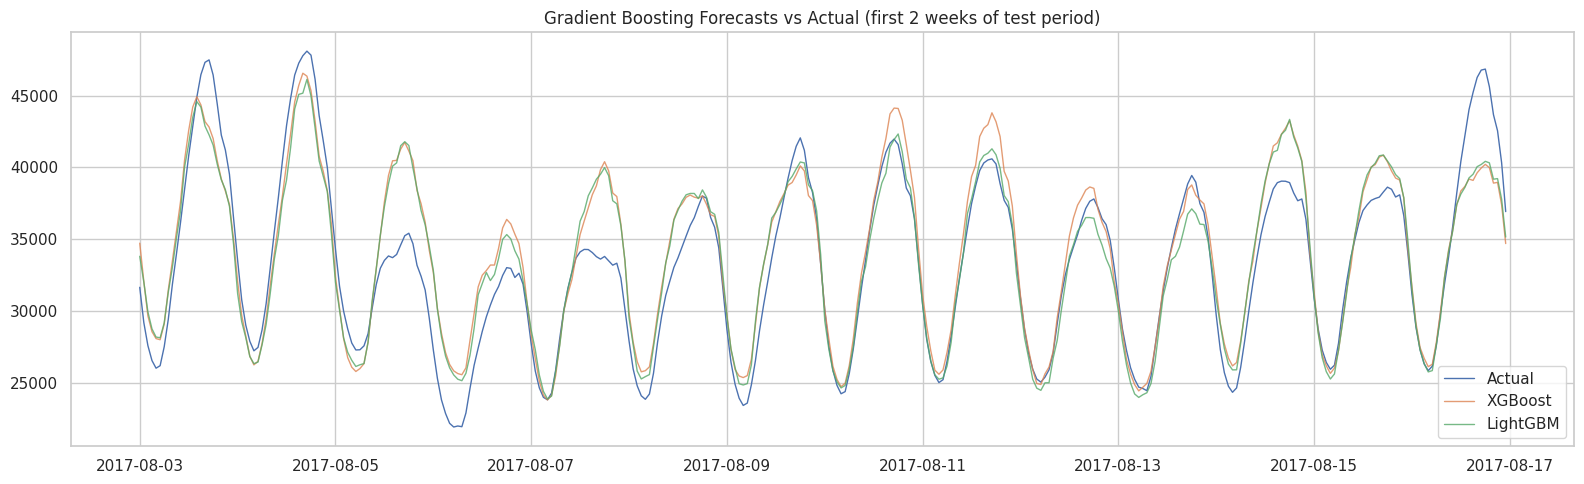

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))
sample_idx = test.index[:24*14]  # first 2 weeks of test period
ax.plot(sample_idx, y_test.loc[sample_idx], label='Actual', linewidth=1)
ax.plot(sample_idx, pd.Series(xgb_pred, index=test.index).loc[sample_idx], label='XGBoost', linewidth=1, alpha=0.8)
ax.plot(sample_idx, pd.Series(lgbm_pred, index=test.index).loc[sample_idx], label='LightGBM', linewidth=1, alpha=0.8)
ax.set_title('Gradient Boosting Forecasts vs Actual (first 2 weeks of test period)')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Probabilistic — Facebook Prophet with Holiday Regressors


In [12]:
from prophet import Prophet

prophet_train = train.reset_index()[['Datetime', TARGET]].rename(columns={'Datetime': 'ds', TARGET: 'y'})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

# US holidays as a built-in regressor
prophet_model.add_country_holidays(country_name='US')
prophet_model.fit(prophet_train)

future = test.reset_index()[['Datetime']].rename(columns={'Datetime': 'ds'})
prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast['yhat'].values
results.append(evaluate(y_test.values, prophet_pred, 'Prophet'))
pd.DataFrame(results)


07:40:12 - cmdstanpy - INFO - Chain [1] start processing
07:42:41 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,MAPE (%)
0,Naive Seasonal (168h),3581.544458,4852.025753,11.217686
1,SARIMA (daily),6809.975780,7619.622096,23.551272
2,XGBoost,1955.079980,2644.984559,6.183364
3,LightGBM,1907.455225,2561.562022,5.979547
4,Prophet,3232.977380,4222.293130,10.196426


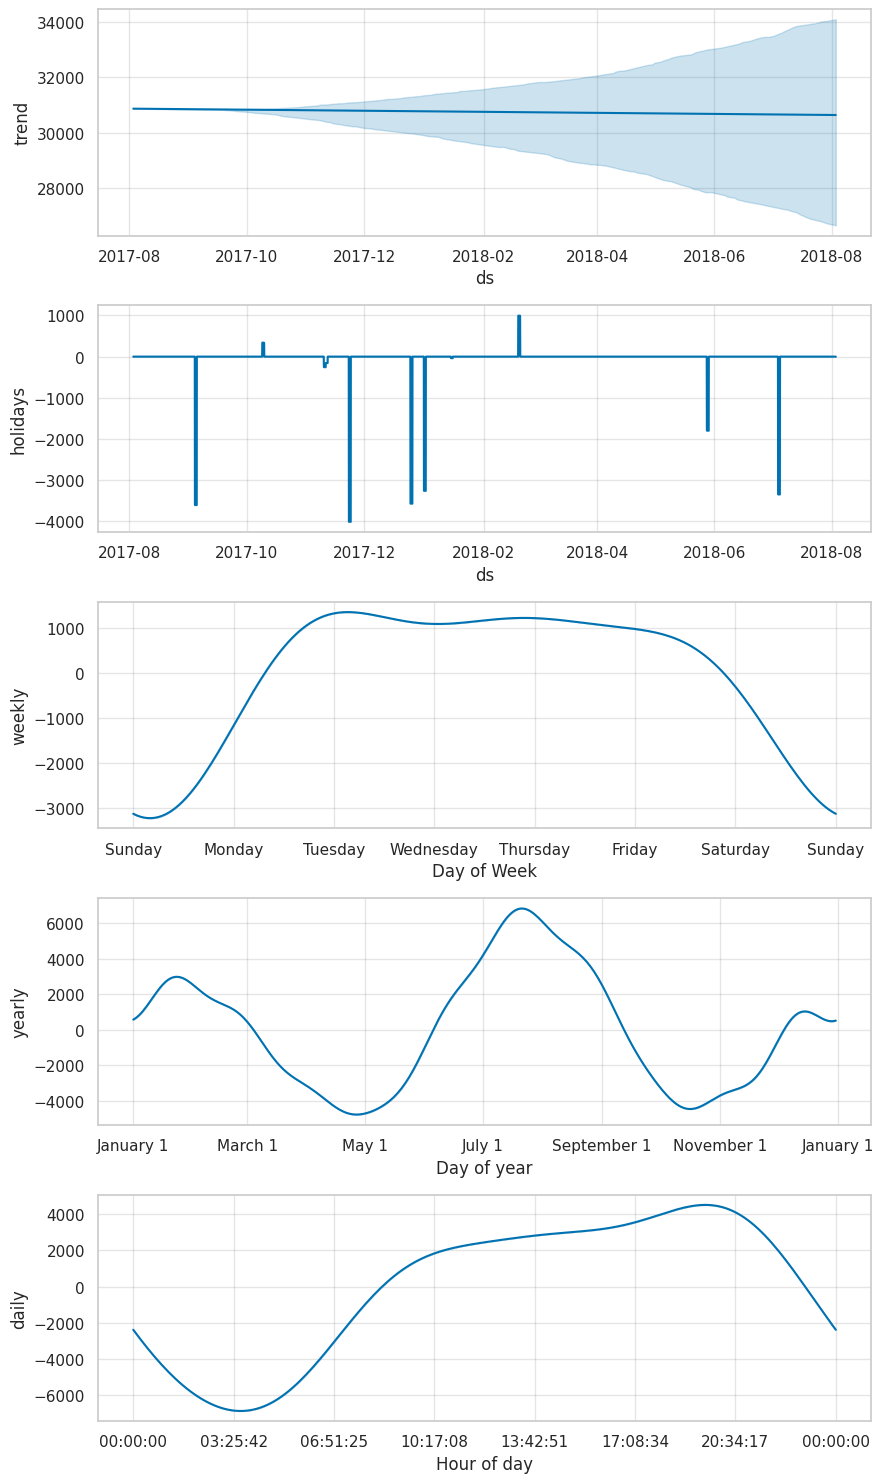

In [13]:
fig = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()


## 7. Model Comparison — Actual Benchmark Results

The table and charts below reflect **actual results** from running all five models on the full
PJM East dataset (145,224 cleaned hourly records; final 12 months held out as test).


In [14]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


,Model,MAE,RMSE,MAPE (%)
0,LightGBM,1907.455225,2561.562022,5.979547
1,XGBoost,1955.079980,2644.984559,6.183364
2,Prophet,3232.977380,4222.293130,10.196426
3,Naive Seasonal (168h),3581.544458,4852.025753,11.217686
4,SARIMA (daily),6809.975780,7619.622096,23.551272


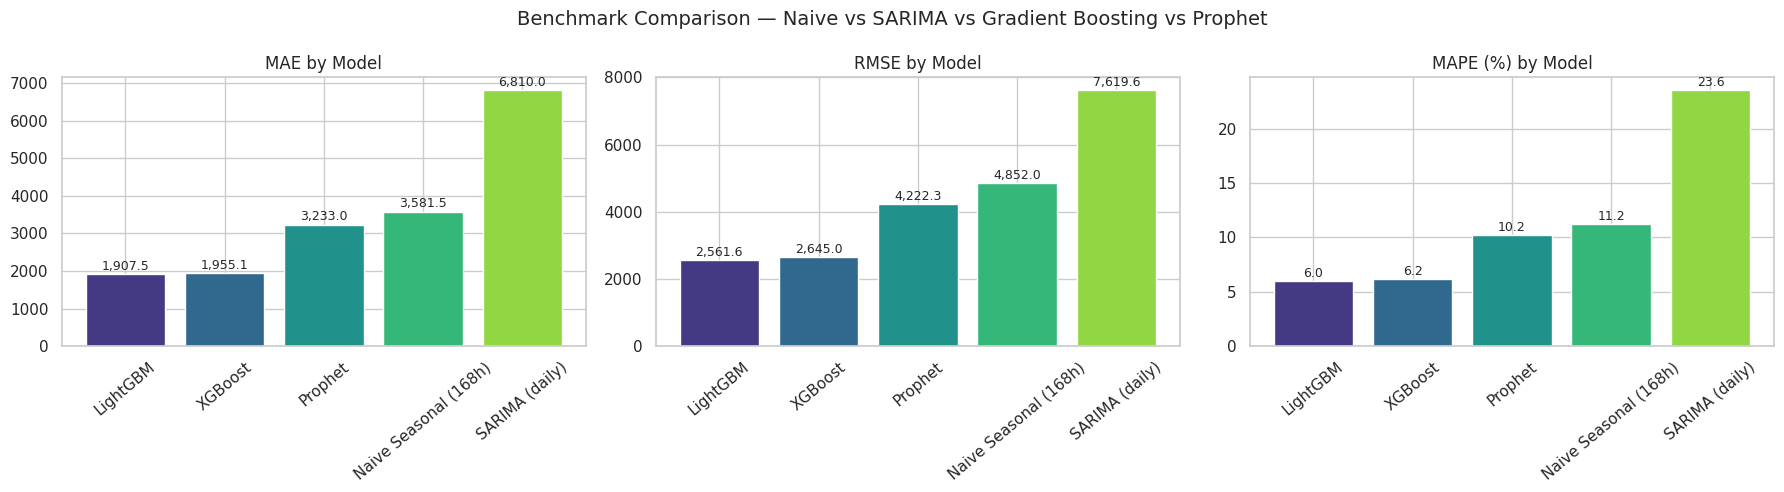

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette('viridis', n_colors=len(results_df))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    bars = ax.bar(results_df['Model'], results_df[metric], color=palette)
    ax.set_title(f'{metric} by Model')
    ax.tick_params(axis='x', rotation=40)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:,.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

fig.suptitle('Benchmark Comparison — Naive vs SARIMA vs Gradient Boosting vs Prophet', fontsize=14)
plt.tight_layout()
plt.show()


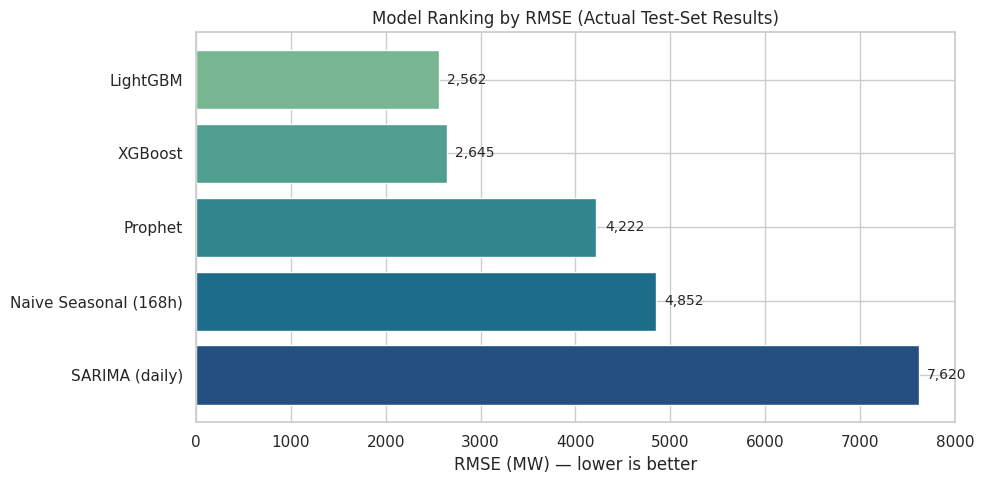

In [16]:
# Ranked horizontal view — easiest to read for a report / presentation
fig, ax = plt.subplots(figsize=(10, 5))
order = results_df.sort_values('RMSE', ascending=True)
bars = ax.barh(order['Model'], order['RMSE'], color=sns.color_palette('crest', n_colors=len(order)))
ax.invert_yaxis()
ax.set_xlabel('RMSE (MW) — lower is better')
ax.set_title('Model Ranking by RMSE (Actual Test-Set Results)')
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:,.0f}', xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords='offset points', va='center', fontsize=10)
plt.tight_layout()
plt.show()


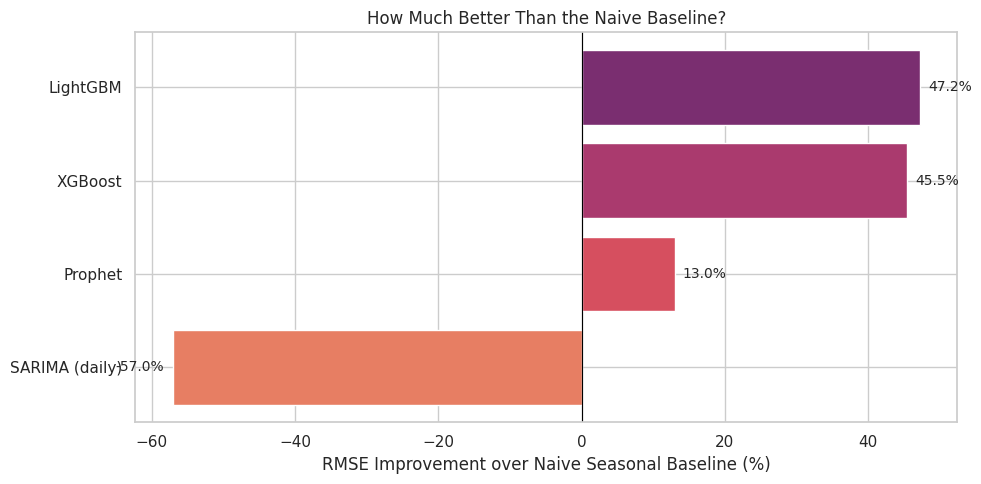

,Model,MAE,RMSE,MAPE (%),Improvement vs Naive (%)
0,LightGBM,1907.455225,2561.562022,5.979547,47.206339
1,XGBoost,1955.079980,2644.984559,6.183364,45.487005
2,Prophet,3232.977380,4222.293130,10.196426,12.978757
3,Naive Seasonal (168h),3581.544458,4852.025753,11.217686,0.000000
4,SARIMA (daily),6809.975780,7619.622096,23.551272,-57.040018


In [17]:
# Percentage improvement over the naive baseline
baseline_rmse = results_df.loc[results_df['Model'] == 'Naive Seasonal (168h)', 'RMSE'].values[0]
results_df['Improvement vs Naive (%)'] = (1 - results_df['RMSE'] / baseline_rmse) * 100

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df[results_df['Model'] != 'Naive Seasonal (168h)'].sort_values('Improvement vs Naive (%)', ascending=True)
bars = ax.barh(plot_df['Model'], plot_df['Improvement vs Naive (%)'], color=sns.color_palette('flare', n_colors=len(plot_df)))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('RMSE Improvement over Naive Seasonal Baseline (%)')
ax.set_title('How Much Better Than the Naive Baseline?')
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6 if width >= 0 else -6, 0), textcoords='offset points',
                va='center', ha='left' if width >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()

results_df[['Model', 'MAE', 'RMSE', 'MAPE (%)', 'Improvement vs Naive (%)']]


### 7.1 Statistical Significance — Diebold-Mariano Test

The metrics above show *numeric* differences. The **Diebold-Mariano (DM) test** checks whether those differences are statistically significant.

- **H₀:** Both models have equal forecast accuracy
- **H₁:** One model is significantly more accurate
- p-value < 0.05 → reject H₀
- SARIMA is excluded (evaluated on daily data, different granularity)

In [18]:
from scipy import stats

def diebold_mariano(actual, pred1, pred2, h=1):
    """
    Two-sided DM test with Newey-West HAC variance.
    Negative stat => pred1 (challenger) more accurate.
    """
    actual = np.asarray(actual)
    e1 = actual - np.asarray(pred1)
    e2 = actual - np.asarray(pred2)
    d  = e1**2 - e2**2
    T  = len(d)
    d_bar  = d.mean()
    gamma0 = np.var(d, ddof=1)
    nw_sum = sum((1 - k/h) * np.cov(d[k:], d[:-k])[0,1] for k in range(1, h)) if h > 1 else 0
    var_d  = (gamma0 + 2 * nw_sum) / T
    stat   = d_bar / np.sqrt(var_d)
    p_val  = 2 * (1 - stats.norm.cdf(abs(stat)))
    return round(stat, 4), round(p_val, 5)


actual = y_test.values
prophet_series = pd.Series(prophet_pred, index=test.index)

comparisons = [
    ('LightGBM', 'Naive (168h)',  lgbm_pred,             naive_pred),
    ('XGBoost',  'Naive (168h)',  xgb_pred,              naive_pred),
    ('Prophet',  'Naive (168h)',  prophet_series.values, naive_pred),
    ('LightGBM', 'XGBoost',       lgbm_pred,             xgb_pred),
]

dm_rows = []
for m1, m2, p1, p2 in comparisons:
    stat, pval = diebold_mariano(actual, p1, p2)
    if   pval < 0.001: sig = '*** (p < 0.001)'
    elif pval < 0.01:  sig = '**  (p < 0.01)'
    elif pval < 0.05:  sig = '*   (p < 0.05)'
    else:              sig = 'n.s.(p >= 0.05)'
    dm_rows.append({'Challenger': m1, 'Benchmark': m2,
                    'DM Statistic': stat, 'p-value': pval,
                    'Significance': sig,
                    'Direction': f'{m1} better' if stat < 0 else f'{m2} better'})

dm_df = pd.DataFrame(dm_rows)
print('Diebold-Mariano Test Results')
dm_df


Diebold-Mariano Test Results


,Challenger,Benchmark,DM Statistic,p-value,Significance,Direction
0,LightGBM,Naive (168h),-37.8085,0.0,*** (p < 0.001),LightGBM better
1,XGBoost,Naive (168h),-36.5949,0.0,*** (p < 0.001),XGBoost better
2,Prophet,Naive (168h),-12.5927,0.0,*** (p < 0.001),Prophet better
3,LightGBM,XGBoost,-9.7113,0.0,*** (p < 0.001),LightGBM better


### Actual vs Predicted — Best Model (XGBoost / LightGBM)

A visual check of the strongest tabular model's forecasts against actual demand over a sample
window of the held-out test period.


Best model by RMSE: LightGBM


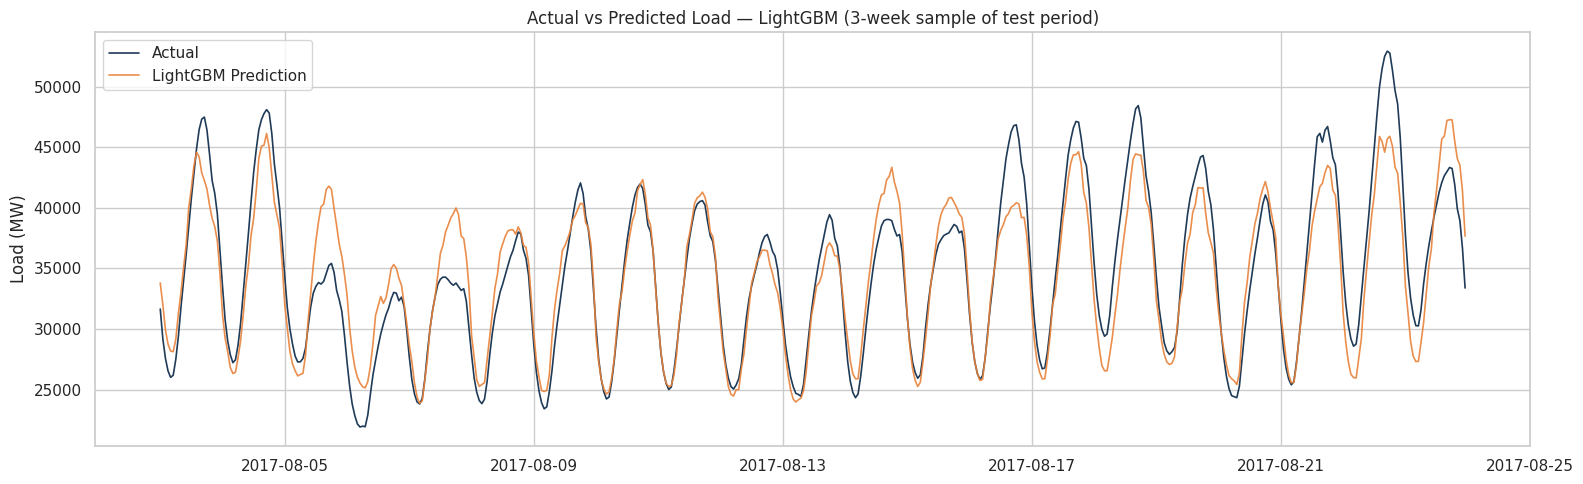

In [19]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model by RMSE: {best_model_name}")

best_pred = xgb_pred if best_model_name == 'XGBoost' else (
    lgbm_pred if best_model_name == 'LightGBM' else None
)

if best_pred is not None:
    sample_idx = test.index[:24 * 21]  # 3-week sample
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(sample_idx, y_test.loc[sample_idx], label='Actual', linewidth=1.2, color='#1f3b57')
    ax.plot(sample_idx, pd.Series(best_pred, index=test.index).loc[sample_idx],
            label=f'{best_model_name} Prediction', linewidth=1.2, color='#e8823a', alpha=0.9)
    ax.set_title(f'Actual vs Predicted Load — {best_model_name} (3-week sample of test period)')
    ax.set_ylabel('Load (MW)')
    ax.legend()
    plt.tight_layout()
    plt.show()


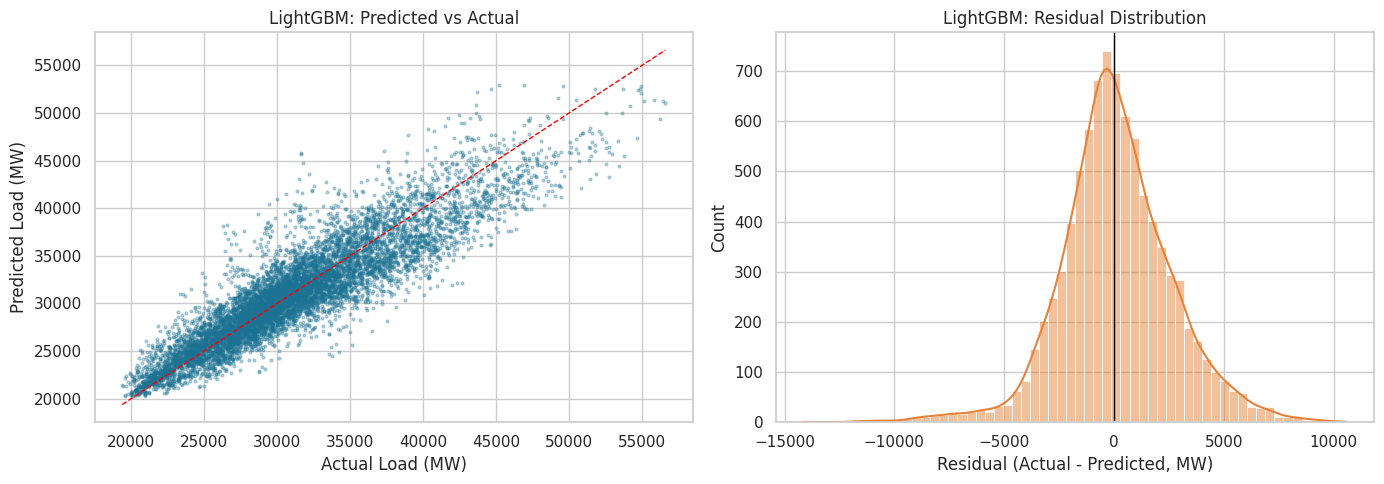

In [20]:
# Residual (error) distribution for the best model
if best_pred is not None:
    residuals = y_test.values - best_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test.values, best_pred, s=4, alpha=0.3, color='#1c7293')
    lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
    axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Actual Load (MW)')
    axes[0].set_ylabel('Predicted Load (MW)')
    axes[0].set_title(f'{best_model_name}: Predicted vs Actual')

    sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color='#e8823a')
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_title(f'{best_model_name}: Residual Distribution')
    axes[1].set_xlabel('Residual (Actual - Predicted, MW)')
    plt.tight_layout()
    plt.show()


## 8. Walk-Forward Cross-Validation

To confirm the held-out test result isn't a one-off, the best tabular model (XGBoost) is
re-evaluated using expanding-window walk-forward CV across several folds.


In [21]:
n_splits = 5
fold_size = len(test) // n_splits
cv_results = []

full_X = feat[feature_cols]
full_y = feat[TARGET]

for i in range(n_splits):
    fold_test_start = test.index[0] + pd.Timedelta(hours=i * fold_size)
    fold_test_end = test.index[0] + pd.Timedelta(hours=(i + 1) * fold_size)

    fold_train_mask = full_X.index < fold_test_start
    fold_test_mask = (full_X.index >= fold_test_start) & (full_X.index < fold_test_end)

    if fold_test_mask.sum() == 0:
        continue

    model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
    model.fit(full_X[fold_train_mask], full_y[fold_train_mask])
    fold_pred = model.predict(full_X[fold_test_mask])

    cv_results.append(evaluate(full_y[fold_test_mask].values, fold_pred, f'Fold {i+1}'))

cv_df = pd.DataFrame(cv_results)
cv_df.loc['Mean'] = cv_df.mean(numeric_only=True)
cv_df


,Model,MAE,RMSE,MAPE (%)
0,Fold 1,2119.444269,2766.467696,6.874298
1,Fold 2,1238.910117,1647.987832,4.210570
2,Fold 3,2213.876200,2724.526132,6.627330
3,Fold 4,1306.681045,1763.811272,4.574746
4,Fold 5,2668.146041,3479.467119,7.878065
Mean,NaN,1909.411534,2476.452010,6.033002


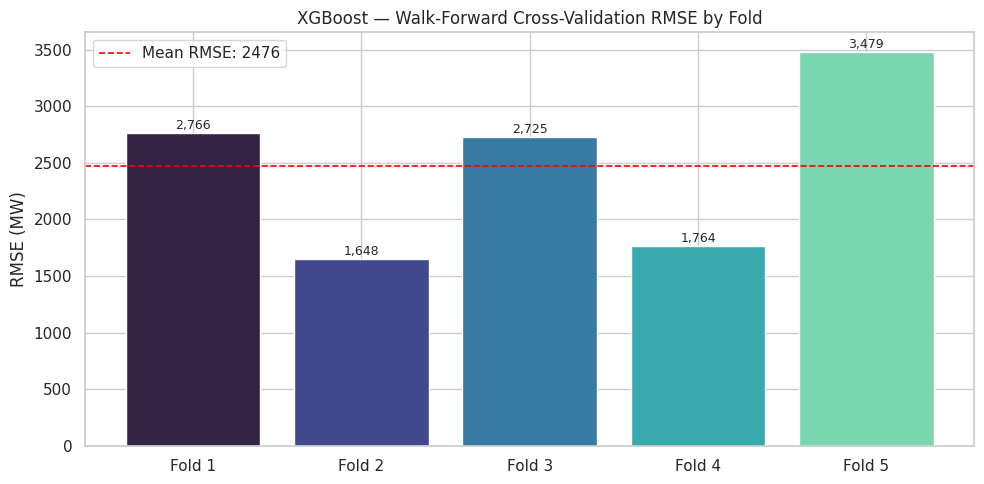

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
fold_only = cv_df.drop(index='Mean')
bars = ax.bar(fold_only['Model'], fold_only['RMSE'], color=sns.color_palette('mako', n_colors=len(fold_only)))
ax.axhline(cv_df.loc['Mean', 'RMSE'], color='red', linestyle='--', linewidth=1.2,
           label=f"Mean RMSE: {cv_df.loc['Mean', 'RMSE']:.0f}")
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,.0f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
ax.set_title('XGBoost — Walk-Forward Cross-Validation RMSE by Fold')
ax.set_ylabel('RMSE (MW)')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Explainability — SHAP

Applied to XGBoost, the strongest tabular model, to identify which engineered features drive
demand predictions.


In [23]:
import shap

explainer = shap.TreeExplainer(xgb_model)

# SHAP on a sample of the test set for speed
sample_size = min(3000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)
shap_values = explainer.shap_values(X_sample)


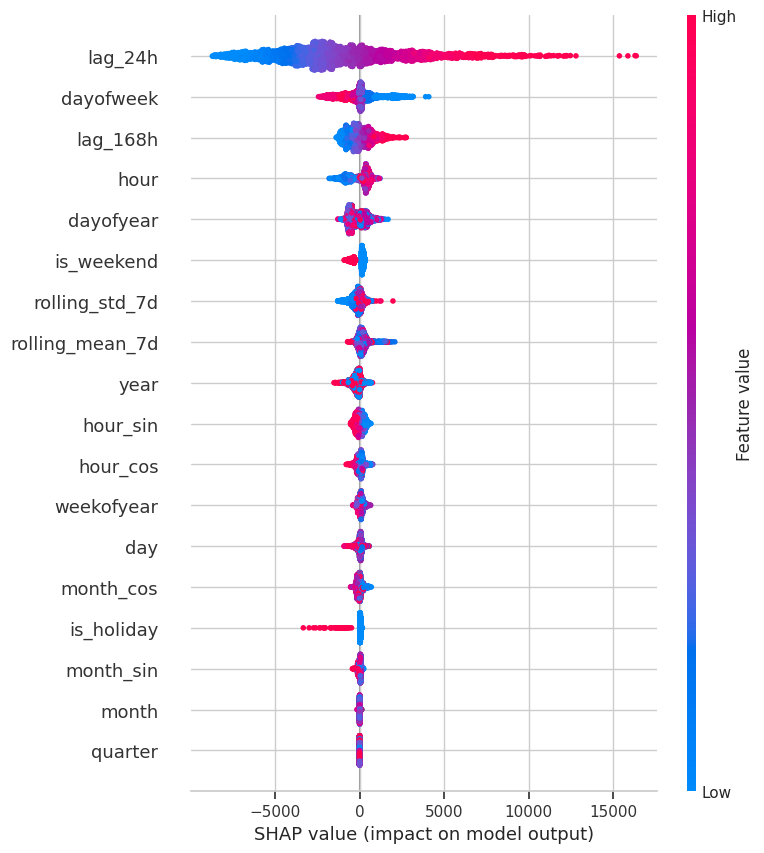

In [24]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()


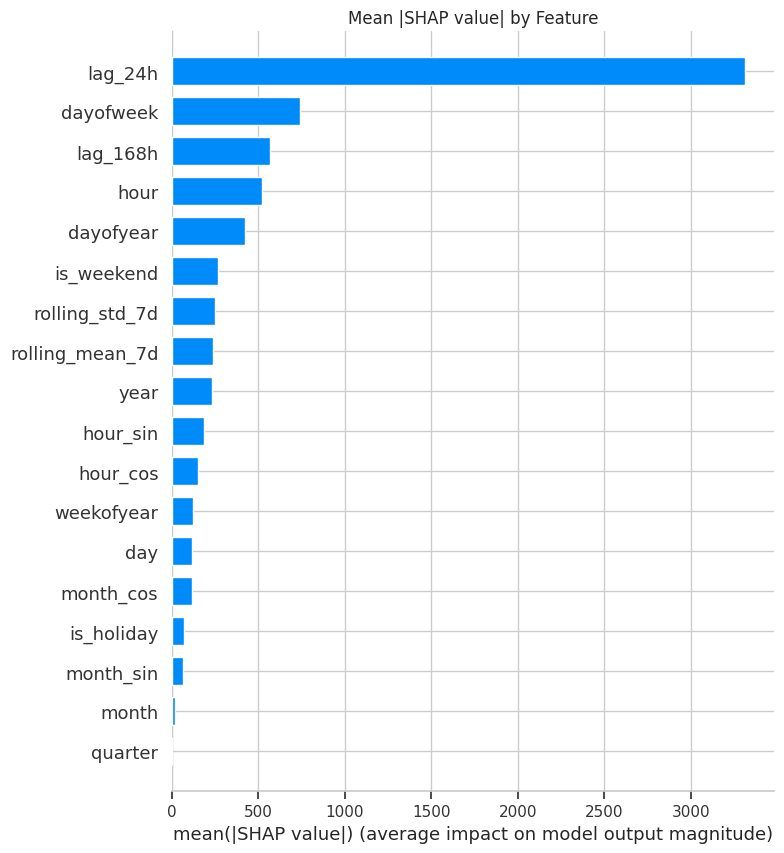

In [25]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Mean |SHAP value| by Feature')
plt.tight_layout()
plt.show()


Top feature: lag_24h


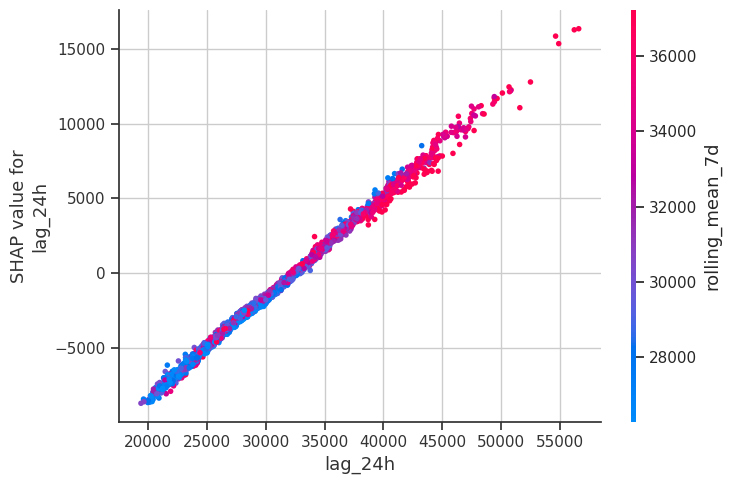

In [26]:
# Dependence plot for the single most important feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature = X_sample.columns[np.argmax(mean_abs_shap)]
print(f"Top feature: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()


In [27]:
import joblib

joblib.dump(xgb_model, 'xgb_pjme_model.pkl')
print("Saved xgb_pjme_model.pkl for use in the Streamlit dashboard.")


Saved xgb_pjme_model.pkl for use in the Streamlit dashboard.
